# Machine Learning for Mental Health Prediction
## Using Synthetic MIMIC-III Clinical Database

**Objectives:**
- Predict in-hospital mental health diagnoses


## 1. Environment Setup & Library Imports

In [ ]:
# Core libraries
import numpy as np # Numerical computing library for array operations
import pandas as pd # Data manipulation and analysis library
import matplotlib.pyplot as plt # Plotting library for creating static, interactive, and animated visualizations
import matplotlib.gridspec as gridspec # Module for creating flexible subplots layouts
import seaborn as sns # Data visualization library based on matplotlib, providing a high-level interface

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score # Utilities for splitting data, cross-validation
from sklearn.preprocessing import StandardScaler, LabelEncoder # Tools for data scaling and encoding categorical features
from sklearn.linear_model import LogisticRegression # Logistic Regression classifier
from sklearn.ensemble import RandomForestClassifier # Ensemble methods for classification
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.metrics import ( # Metrics for evaluating model performance
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline # Utility for chaining multiple processing steps
from sklearn.impute import SimpleImputer # Tool for handling missing values
from sklearn.feature_selection import SelectFromModel # Tool for selecting features based on importance

# XGBoost
try:
    import xgboost as xgb # Gradient boosting library for tree-based models
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

# SMOTE for class imbalance
try:
    from imblearn.over_sampling import SMOTE # Synthetic Minority Over-sampling Technique for imbalanced datasets
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False

print('All libraries loaded successfully!')


All libraries loaded successfully!


## 2. Load Data from google drive

 Mental Health Data for this tutorial

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # Mount Google Drive to access stored files,


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/csv/mental_health_patient_data.csv')
print(f'Dataset loaded with {len(df)} rows and {len(df.columns)} columns.')
# display(df.head())

Dataset loaded with 60000 rows and 42 columns.


## 3. Mental Health Dataset Overview

In [ ]:
# Mental Health Dataset Overview
print('=== DATASET SUMMARY ===')
print(f'Total admissions:              {len(df):,}')
print(f'Mental health diagnoses:       {df["has_mental_health_dx"].sum():,} ({df["has_mental_health_dx"].mean():.1%})')
print(f'In-hospital deaths:            {df["hospital_expire_flag"].sum():,} ({df["hospital_expire_flag"].mean():.1%})')
print(f'ICU patients:                  {df["icu_flag"].sum():,} ({df["icu_flag"].mean():.1%})')
print(f'\nAge: Mean={df["age"].mean():.1f}, Median={df["age"].median():.1f}, Std={df["age"].std():.1f}')
print(f'LOS: Mean={df["los_days"].mean():.1f}d, Median={df["los_days"].median():.1f}d')
# print(f'\nMissing values: {df.isnull().sum()}')

=== DATASET SUMMARY ===
Total admissions:              60,000
Mental health diagnoses:       10,777 (18.0%)
In-hospital deaths:            5,132 (8.6%)
ICU patients:                  22,943 (38.2%)

Age: Mean=61.9, Median=62.0, Std=16.6
LOS: Mean=5.5d, Median=3.8d


In [ ]:
print("\n:===============================:\n")
print("\nTarget Distribution:\n", df['has_mental_health_dx'].value_counts(normalize=True))


:===============================:


Target Distribution:
 has_mental_health_dx
0    0.820383
1    0.179617
Name: proportion, dtype: float64


## 4. **Mental Health Data Discovery**
1. Age Distribution by MH Status
2. Length of Stay Distribution
  - compare the length of stay (LOS) in  days between patients with and without a mental health diagnosis.
3. MH Diagnosis Percentage by Insurance
  - The percentage of patients with and without a mental health diagnosis across different insurance types. This will help understand the relationship between insurance coverage and mental health diagnoses.
4. Risk Factor Prevalence by MH Status
  - The prevalence of various risk factors (e.g., 'prev_psych_meds', 'substance_use_hx', 'trauma_hx', 'social_support_poor', 'sleep_disorder') for patients with and without a mental health diagnosis. This will help compare how these risk factors differ across the two groups.
5. Number of Medications Distribution by MH Status
 - Compare the distribution of 'num_medications' for patients, segmented by their mental health diagnosis status.


In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import plotly.graph_objects as go

# Define the color_map and create the has_mental_health_dx_label column
color_map = {0: 'No MH Dx', 1: 'MH Dx'}
df['has_mental_health_dx_label'] = df['has_mental_health_dx'].map(color_map)

# Calculate the mh_counts DataFrame
mh_counts = df['has_mental_health_dx'].value_counts().reset_index()
mh_counts.columns = ['has_mental_health_dx', 'count']
mh_counts['percentage'] = (mh_counts['count'] / mh_counts['count'].sum()) * 100
mh_counts['has_mental_health_dx_label'] = mh_counts['has_mental_health_dx'].map(color_map)

# Calculate the ins_mh_pct_melted DataFrame
ins_mh = df.groupby(['insurance', 'has_mental_health_dx_label']).size().unstack(fill_value=0)
ins_mh_pct = ins_mh.div(ins_mh.sum(axis=1), axis=0) * 100
ins_mh_pct_melted = ins_mh_pct.reset_index().melt(id_vars=['insurance'], var_name='Mental Health Status', value_name='Percentage')

# Define risk_factors and calculate prevalence rates
risk_factors = ['prev_psych_meds', 'substance_use_hx', 'trauma_hx', 'social_support_poor', 'sleep_disorder']
rf_rates_mh = df[df['has_mental_health_dx'] == 1][risk_factors].mean() * 100
rf_rates_no = df[df['has_mental_health_dx'] == 0][risk_factors].mean() * 100
rf_df = pd.DataFrame({
    'Risk Factor': risk_factors,
    'No MH Dx': rf_rates_no.values,
    'MH Dx': rf_rates_mh.values
})
rf_df_melted = rf_df.melt(id_vars=['Risk Factor'], var_name='Mental Health Status', value_name='Prevalence (%)')
x_axis_labels = {
    'prev_psych_meds': 'Psych Meds',
    'substance_use_hx': 'Substance Use',
    'trauma_hx': 'Trauma Hx',
    'social_support_poor': 'Poor Social Support',
    'sleep_disorder': 'Sleep Disorder'
}
rf_df_melted['Risk Factor Label'] = rf_df_melted['Risk Factor'].map(x_axis_labels)

# Initialize a plotly.subplots.make_subplots figure
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Mental Health Diagnosis Distribution',
        'Age Distribution by Mental Health Status',
        'Length of Stay (days) by Mental Health Status',
        'MH Diagnosis Percentage by Insurance Type',
        'Risk Factor Prevalence by Mental Health Status',
        'Number of Medications by Mental Health Status'
    )
)

# Define common colors
COLOR_NO_MH = '#0D7377'
COLOR_MH = '#E05C5C'

# 'Mental Health Diagnosis Distribution'
fig1 = px.bar(
    mh_counts,
    x='has_mental_health_dx_label',
    y='count',
    color='has_mental_health_dx_label',
    color_discrete_map={'No MH Dx': COLOR_NO_MH, 'MH Dx': COLOR_MH}
)
for trace in fig1.data:
    fig.add_trace(go.Bar(trace, showlegend=True, name=trace.name),
                  row=1, col=1)

# 'Age Distribution by Mental Health Status'
fig2 = px.histogram(
    df,
    x='age',
    color='has_mental_health_dx_label',
    color_discrete_map={'No MH Dx': COLOR_NO_MH, 'MH Dx': COLOR_MH},
    nbins=20,
    barmode='overlay',
    opacity=0.7
)
for trace in fig2.data:
    fig.add_trace(go.Histogram(trace, name=trace.name),
                  row=1, col=2)

# 'Length of Stay (days) by Mental Health Status'
fig3 = px.box(
    df,
    x='has_mental_health_dx_label',
    y='los_days',
    color='has_mental_health_dx_label',
    color_discrete_map={'No MH Dx': COLOR_NO_MH, 'MH Dx': COLOR_MH},
    points="outliers"
)
for trace in fig3.data:
    fig.add_trace(go.Box(trace, name=trace.name),
                  row=1, col=3)

# 'MH Diagnosis Percentage by Insurance Type'
fig4 = px.bar(
    ins_mh_pct_melted,
    x='insurance',
    y='Percentage',
    color='Mental Health Status',
    color_discrete_map={'No MH Dx': COLOR_NO_MH, 'MH Dx': COLOR_MH},
    barmode='group'
)
for trace in fig4.data:
    fig.add_trace(go.Bar(trace, showlegend= False, name=trace.name),
                  row=2, col=1)

# 'Risk Factor Prevalence by Mental Health Status'
fig5 = px.bar(
    rf_df_melted,
    x='Risk Factor Label',
    y='Prevalence (%)',
    color='Mental Health Status',
    color_discrete_map={'No MH Dx': COLOR_NO_MH, 'MH Dx': COLOR_MH},
    barmode='group'
)
for trace in fig5.data:
    fig.add_trace(go.Bar(trace, name=trace.name),
                  row=2, col=2)

# 'Number of Medications by Mental Health Status'
fig6 = px.box(
    df,
    x='has_mental_health_dx_label',
    y='num_medications',
    color='has_mental_health_dx_label',
    color_discrete_map={'No MH Dx': COLOR_NO_MH, 'MH Dx': COLOR_MH},
    points="outliers"
)
for trace in fig6.data:
    fig.add_trace(go.Box(trace, showlegend= False, name=trace.name),
                  row=2, col=3)

# Update axis labels manually for subplots
fig.update_xaxes(title_text='Mental Health Diagnosis', row=1, col=1)
fig.update_yaxes(title_text='Number of Patients', row=1, col=1)

fig.update_xaxes(title_text='Age (Years)', row=1, col=2)
fig.update_yaxes(title_text='Count', row=1, col=2)

fig.update_xaxes(title_text='Mental Health Status', row=1, col=3)
fig.update_yaxes(title_text='Length of Stay (days)', row=1, col=3)

fig.update_xaxes(title_text='Insurance Type', row=2, col=1)
fig.update_yaxes(title_text='Percentage (%)', row=2, col=1)

fig.update_xaxes(title_text='Risk Factor', row=2, col=2)
fig.update_yaxes(title_text='Prevalence (%)', row=2, col=2)

fig.update_xaxes(title_text='Mental Health Status', row=2, col=3)
fig.update_yaxes(title_text='Number of Medications', row=2, col=3)


# Update the layout of the make_subplots figure
fig.update_layout(
    title_text='Comprehensive Mental Health Data Overview',
    title_x=0.5,
    height=800,
    width=1300,
    showlegend=True,
    font=dict(family="Arial", size=12, color="black"),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Display the combined figure
fig.show()


## 5. Feature Engineering & Preprocessing
-  Handle class imbalance with SMOTE

In [ ]:
import numpy as np
import pandas as pd

# Feature Engineering
df_model = df.copy()

# Derived features
df_model['age_group'] = pd.cut(df_model['age'], bins=[0,35,50,65,80,100],
                                labels=['18-35','36-50','51-65','66-80','80+'])
df_model['los_group'] = pd.cut(df_model['los_days'], bins=[0,2,7,14,30,100],
                                labels=['<2d','2-7d','8-14d','15-30d','>30d'])
df_model['polypharmacy'] = (df_model['num_medications'] >= 10).astype(int)
df_model['acute_admission'] = (df_model['admission_type'].isin(['EMERGENCY','URGENT'])).astype(int)
df_model['bun_creatinine_ratio'] = df_model['bun'] / df_model['creatinine'].clip(0.1, None)
df_model['anemia_flag'] = (df_model['hemoglobin'] < 10).astype(int)
df_model['hyponatremia'] = (df_model['sodium'] < 135).astype(int)
df_model['hyperglycemia'] = (df_model['glucose'] > 180).astype(int)
df_model['mh_risk_index'] = (
    df_model['prev_psych_meds'] * 2 +
    df_model['substance_use_hx'] * 2 +
    df_model['trauma_hx'] * 1.5 +
    df_model['social_support_poor'] * 1 +
    df_model['prior_mh_admissions']
)

# Encode categoricals
cat_cols = ['gender', 'ethnicity', 'insurance', 'marital_status', 'admission_type', 'age_group', 'los_group']
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Drop non-feature columns and NLP related features, and the auxillary mental health label column
drop_cols = [
    'hadm_id', 'subject_id', 'readmit_30d', 'hospital_expire_flag',
    'note_depression_score', 'note_anxiety_score', 'note_psychosis_score', 'note_suicide_risk',
    'has_mental_health_dx_label' # Exclude this string column from features
]
feature_cols = [c for c in df_encoded.columns if c not in drop_cols + ['has_mental_health_dx']]

X = df_encoded[feature_cols].astype(float)
y = df_encoded['has_mental_health_dx']

print(f'Feature matrix shape: {X.shape}')
print(f'Features engineered: {len(feature_cols)}')
print(f'Class balance: {y.value_counts().to_dict()}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


# Handle class imbalance with SMOTE
if IMBLEARN_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
    # Format the print statement to evaluate the dictionary comprehension
    smote_balance = {int(k): int(v) for k, v in zip(*np.unique(y_train_bal, return_counts=True))}
    print(f'\nAfter SMOTE: {smote_balance}')
else:
    X_train_bal, y_train_bal = X_train_sc, y_train
    print('\nSMOTE not available.')

print('\n ============ Preprocessing complete ================')

Feature matrix shape: (60000, 60)
Features engineered: 60
Class balance: {0: 49223, 1: 10777}

After SMOTE: {0: 39378, 1: 39378}

 ============ Preprocessing complete ================


## 6. Model Training & Evaluation

In [ ]:
#Model Definitions
models = {
    'Logistic Regression': LogisticRegression(
        C=0.1, max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
  }

if XGB_AVAILABLE:
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )

# Train & Evaluate
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    auroc = roc_auc_score(y_test, y_proba)
    auprc = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'model': model,
        'y_proba': y_proba,
        'y_pred': y_pred,
        'AUROC': auroc,
        'AUPRC': auprc,
        'F1': f1,
        'Precision': prec,
        'Recall': rec,
       }
    print(f'  AUROC={auroc:.3f} | F1={f1:.3f} ')

# Results table
results_df = pd.DataFrame({
    name: {
        'AUROC': v['AUROC'],
        'AUPRC': v['AUPRC'],
        'F1': v['F1'],
        'Precision': v['Precision'],
        'Recall': v['Recall'],
    }
    for name, v in results.items()
}).T

print('\n===== MODEL PERFORMANCE COMPARISON =====')
print(results_df.to_string())


Training Logistic Regression...
  AUROC=0.805 | F1=0.503 

Training Random Forest...
  AUROC=0.794 | F1=0.481 

Training XGBoost...
  AUROC=0.795 | F1=0.492 

===== MODEL PERFORMANCE COMPARISON =====
                        AUROC     AUPRC        F1  Precision    Recall
Logistic Regression  0.804909  0.514244  0.503487   0.387032  0.720186
Random Forest        0.794132  0.483485  0.481387   0.479724  0.483063
XGBoost              0.794924  0.494516  0.492010   0.377228  0.707193


### **Visualize the results**


In [ ]:
results_df_reset = results_df.reset_index()
results_df_reset.rename(columns={'index': 'Model'}, inplace=True)

# Select the relevant columns
metrics_to_melt = ['Model', 'AUROC', 'AUPRC', 'F1', 'Precision', 'Recall']
selected_metrics_df = results_df_reset[metrics_to_melt]

# Melt the DataFrame to long format
plot_df_metrics = selected_metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Value')
# print(plot_df_metrics.head(26))

In [ ]:
import plotly.express as px

#  The grouped bar chart
fig = px.bar(plot_df_metrics,
             x='Metric',
             y='Value',
             color='Model',
             barmode='group',
             title='Model Performance Metrics Comparison',
             labels={'Value': 'Score', 'Metric': 'Performance Metric'},
             height=600,
             width=1000)
fig.update_layout(
    xaxis_title='Performance Metric',
    yaxis_title='Score',
    legend_title='Model',
    yaxis_range=[0, 1.05], # Ensure y-axis starts at 0 and goes slightly above 1 for better visibility
    font=dict(family="Arial", size=12, color="black"),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

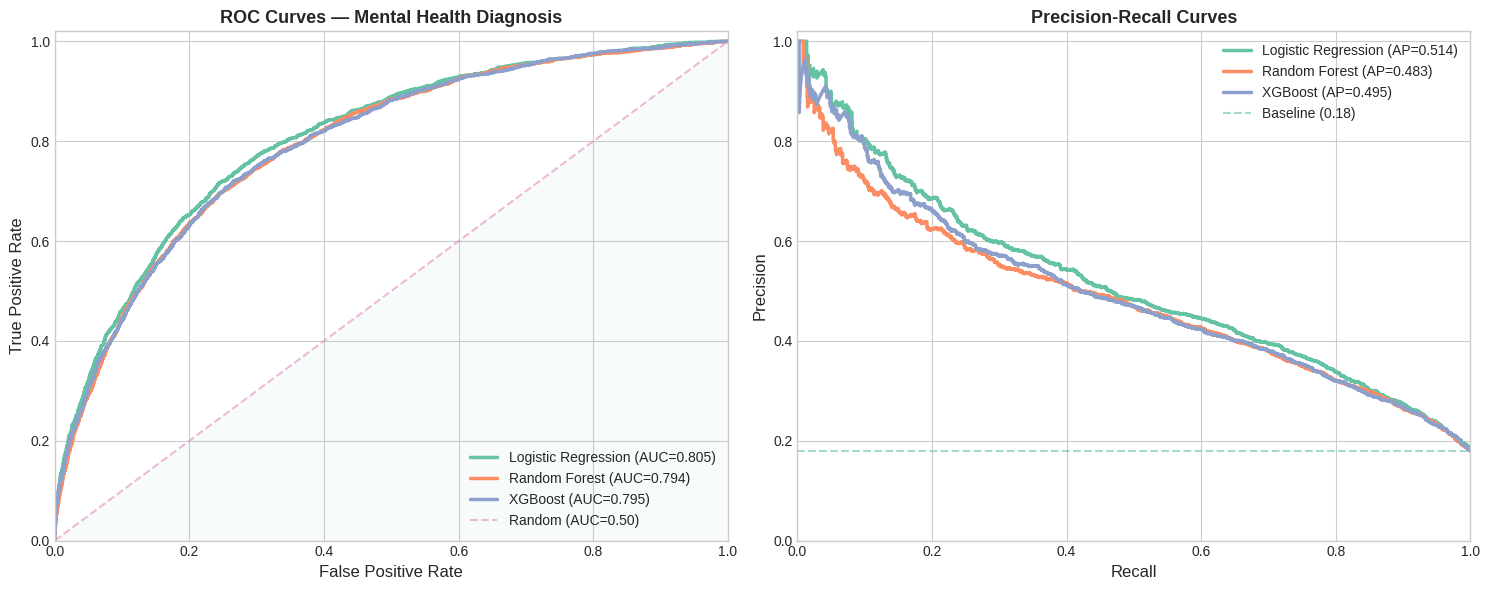

In [ ]:
# ROC & PR Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


for i, (name, res) in enumerate(results.items()):

    # ROC
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, lw=2.5,
                  label=f"{name} (AUC={res['AUROC']:.3f})")

    # PR Curve
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec_arr, prec_arr, lw=2.5,
                  label=f"{name} (AP={res['AUPRC']:.3f})")

# ROC baseline
axes[0].plot([0,1],[0,1],'--', alpha=0.6, label='Random (AUC=0.50)')
axes[0].fill_between([0,1],[0,1], alpha=0.05)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — Mental Health Diagnosis', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# PR baseline
baseline = y_test.mean()
axes[1].axhline(y=baseline, linestyle='--', alpha=0.6, label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall',fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

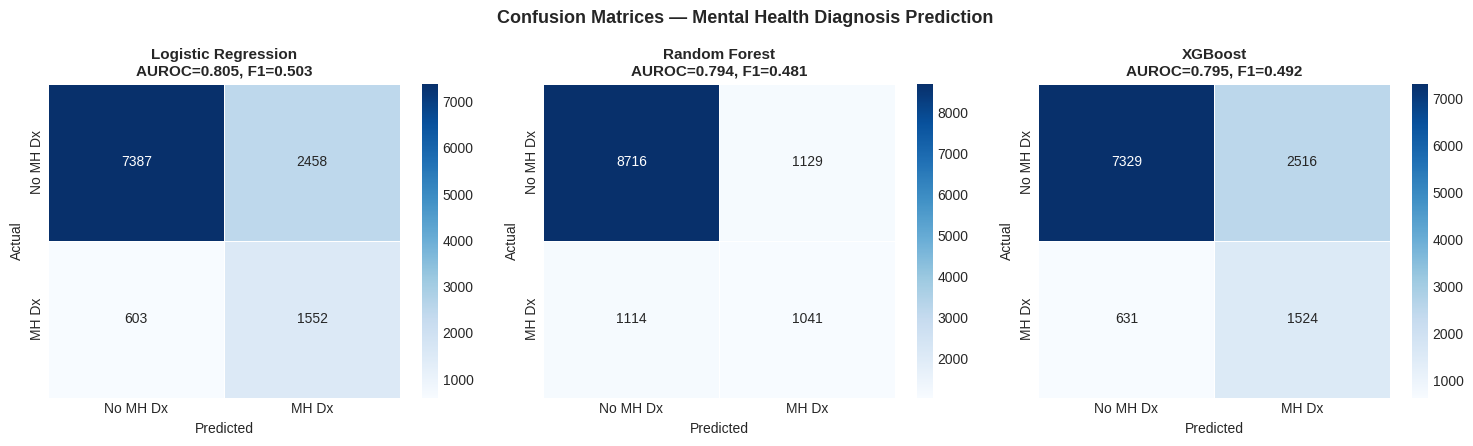

In [ ]:
# Confusion Matrices
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1: axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['No MH Dx', 'MH Dx'],
                yticklabels=['No MH Dx', 'MH Dx'])
    ax.set_title(f'{name}\nAUROC={res["AUROC"]:.3f}, F1={res["F1"]:.3f}',
                  fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Mental Health Diagnosis Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance & Model Interpretability

In [ ]:
feature_importances = {}

# Logistic Regression
if 'Logistic Regression' in results:
    lr_coef = results['Logistic Regression']['model'].coef_[0]
    feature_importances['Logistic Regression'] = pd.Series(lr_coef, index=feature_cols)
    print('Logistic Regression Feature Importances (head):\n', feature_importances['Logistic Regression'].head())

# Random Forest
if 'Random Forest' in results:
    rf_importances = results['Random Forest']['model'].feature_importances_
    feature_importances['Random Forest'] = pd.Series(rf_importances, index=feature_cols)
    print('\nRandom Forest Feature Importances (head):\n', feature_importances['Random Forest'].head())

# XGBoost
if 'XGBoost' in results:
    xgb_importances = results['XGBoost']['model'].feature_importances_
    feature_importances['XGBoost'] = pd.Series(xgb_importances, index=feature_cols)
    print('\nXGBoost Feature Importances (head):\n', feature_importances['XGBoost'].head())


Logistic Regression Feature Importances (head):
 age               0.813715
los_days         -0.093915
icu_flag         -0.039776
num_diagnoses    -0.027535
num_procedures   -0.046599
dtype: float64

Random Forest Feature Importances (head):
 age               0.048075
los_days          0.007069
icu_flag          0.018152
num_diagnoses     0.006018
num_procedures    0.009454
dtype: float64

XGBoost Feature Importances (head):
 age               0.022699
los_days          0.003199
icu_flag          0.049648
num_diagnoses     0.004339
num_procedures    0.015547
dtype: float32


## Normalize Feature Importances

Normalize the extracted feature importances for each model to allow for a fair comparison across models.

In [ ]:
normalized_feature_importances = {}

for model_name, importances in feature_importances.items():
    # Calculate absolute values of importances
    abs_importances = importances.abs()
    # Normalize by dividing by the sum of absolute importances
    normalized_importances = abs_importances / abs_importances.sum()
    normalized_feature_importances[model_name] = normalized_importances

    print(f'\n{model_name} Normalized Feature Importances (head):\n', normalized_feature_importances[model_name].head())


Logistic Regression Normalized Feature Importances (head):
 age               0.173357
los_days          0.020008
icu_flag          0.008474
num_diagnoses     0.005866
num_procedures    0.009928
dtype: float64

Random Forest Normalized Feature Importances (head):
 age               0.048075
los_days          0.007069
icu_flag          0.018152
num_diagnoses     0.006018
num_procedures    0.009454
dtype: float64

XGBoost Normalized Feature Importances (head):
 age               0.022699
los_days          0.003199
icu_flag          0.049648
num_diagnoses     0.004339
num_procedures    0.015547
dtype: float32


## Visualize Comparative Feature Importances

 Visualization to compare the top 10 features and their importances across Logistic Regression, Random Forest, and XGBoost models.

In [ ]:
N = 10  # Number of top features to display

all_top_features = []

for model_name, importances in normalized_feature_importances.items():
    top_n = importances.nlargest(N).reset_index()
    top_n.columns = ['Feature', 'Normalized Importance']
    top_n['Model'] = model_name
    all_top_features.append(top_n)

# Concatenate all top features into a single DataFrame
plot_df = pd.concat(all_top_features, ignore_index=True)

print(f'DataFrame for plotting top {N} features created with shape: {plot_df.shape}')
# print(plot_df.head(50))

DataFrame for plotting top 10 features created with shape: (30, 3)


In [ ]:
import plotly.express as px

# Create the bar chart
fig = px.bar(plot_df,
             x='Normalized Importance',
             y='Feature',
             color='Model',
             barmode='group',
             orientation='h',
             title=f'Top {N} Feature Importances Across Models',
             hover_data={'Normalized Importance': ':.3f'})

# Customize layout
fig.update_layout(
    xaxis_title='Normalized Importance',
    yaxis_title='Feature',
    legend_title='Model',
    height=700,
    width=1000,
    yaxis={'categoryorder':'total ascending'}
)

fig.show()

Extracting feature importance from: Logistic Regression


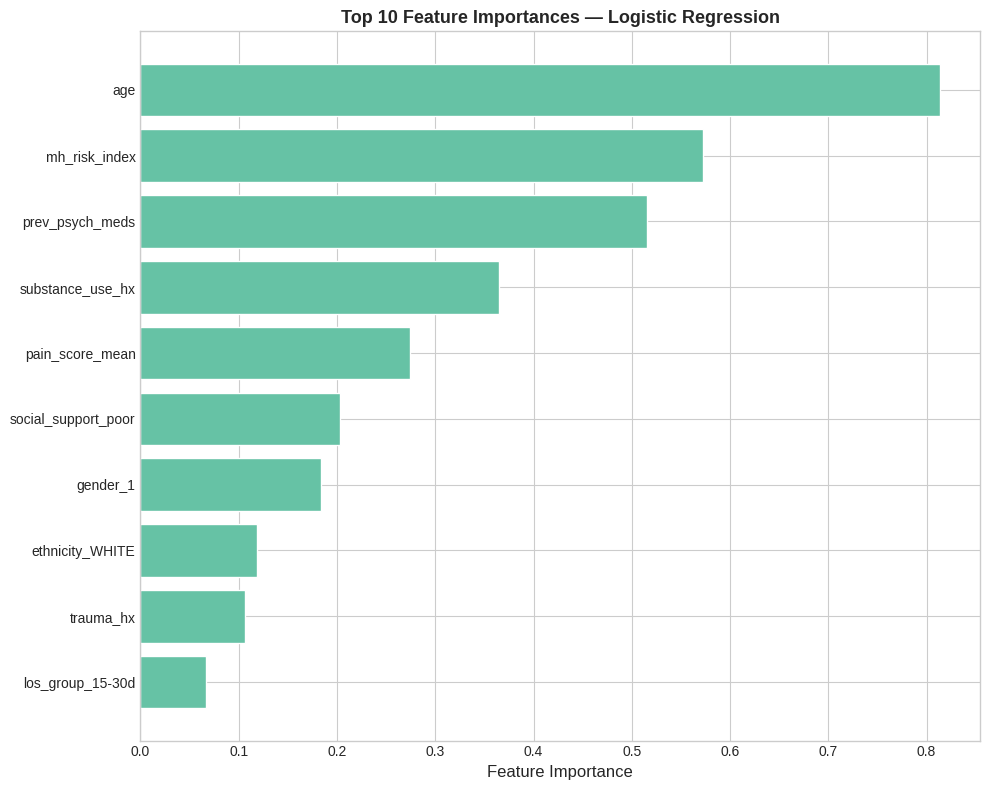

In [ ]:
# Feature Importance - Logistic Regression Model
rf_model_name = 'Logistic Regression'
rf_model = results[rf_model_name]['model']
print(f'Extracting feature importance from: {rf_model_name}')

if hasattr(rf_model, 'coef_'):
    feat_imp = pd.Series(rf_model.coef_[0], index=feature_cols)
    top_features = feat_imp.nlargest(10).sort_values()
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(range(len(top_features)), top_features.values,  edgecolor='white')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features.index, fontsize=10)
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'Top 10 Feature Importances — {rf_model_name}', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(f'{rf_model_name} model does not have feature importances attribute (which is unexpected).')
    top_features = None

## 10. Final Summary & Results
 - **Logistic Regression** showed the best overall performance with the highest AUROC (0.805), AUPRC (0.514), F1-score (0.503), and Recall (0.720). While its precision was lower, its strong performance in other metrics suggests it's effective at identifying mental health diagnoses.
- XGBoost performed comparably to Logistic Regression in terms of AUROC (0.795) and AUPRC (0.495), with a good Recall (0.707), but its Precision was also lower.
- Random Forest had the highest Precision (0.480) but lagged slightly behind the other models in AUROC (0.794), AUPRC (0.483), F1-score (0.481), and Recall (0.483).
- Considering the objective of predicting mental health risk, **Logistic Regression appears to be the most effective model for this dataset, excelling in overall discriminative power (AUROC), capturing positive cases (Recall), and maintaining a good balance of precision and recall (F1).**